In [36]:
import numpy as np
import matplotlib.pyplot as plt


In [37]:
# ============================================================
# 1. DONNÉES DU DATASET (Régression linéaire multiple)
# ============================================================
# Chaque ligne = un étudiant
# Chaque colonne = une variable explicative (X)
# ============================================================
# MODÈLE MATHÉMATIQUE (RÉGRESSION LINÉAIRE MULTIPLE)
# ============================================================
#
# On cherche à modéliser la relation entre les variables
# explicatives et la note finale d’un étudiant.
#
# Forme mathématique du modèle :
#
# Note = a1*x1 + a2*x2 + a3*x3 + a4*x4 + a5*x5 + a6*x6 + b
#
# où :
#
# x1 = heures d’étude
# x2 = sommeil
# x3 = stress
# x4 = participation
# x5 = sport
# x6 = écran
#
# a1, a2, a3, a4, a5, a6 = coefficients (poids de chaque variable)
# b = biais (valeur de base)
#
# Interprétation :
# - Chaque coefficient ai mesure l’impact de la variable xi sur la note
# - Exemple :
#   si a3 (stress) est négatif → plus de stress diminue la note
#   si a1 (heures d’étude) est positif → plus d’étude augmente la note
#
# Objectif du modèle :
# Trouver les valeurs optimales de (a1...a6, b)
# pour minimiser l’erreur entre les notes réelles et prédites.
#
# ============================================================

heures_etude = np.array([2, 4, 6, 8, 10, 3, 7]) #les heures d'étude par semaine
sommeil = np.array([5, 6, 7, 7, 8, 4, 6]) #les heures de sommeil par nuit
stress = np.array([8, 6, 5, 4, 3, 9, 5]) #niveau de stress (1 à 10)
participation = np.array([20, 40, 60, 80, 90, 30, 70]) #participation en classe (%)
sport = np.array([0, 2, 3, 4, 5, 0, 3]) #nombre d'heures de sport par semaine
ecran = np.array([6, 5, 4, 3, 2, 7, 4]) #nombre d'heures passées devant un écran par jour

# Variable cible (Y) : note finale
notes_finales = np.array([10, 13, 15, 17, 18.5, 11, 16])


In [38]:
# ============================================================
# 2. CONSTRUCTION DE LA MATRICE X
# ============================================================
# On regroupe toutes les variables explicatives dans une matrice X

X = np.c_[
    heures_etude,                   #        [ x1  x2  x3  x4  x5  x6 ]
    sommeil,                        #   X =  [ x1  x2  x3  x4  x5  x6 ]
    stress,                         #        [ ...               ...   ]
    participation,
    sport,
    ecran
]
# x1 = heures d’étude
# x2 = sommeil
# x3 = stress
# x4 = participation
# x5 = sport
# x6 = écran

# Nombre d'exemples (lignes)
m = len(X)


In [39]:
# ============================================================
# 3. AJOUT DU BIAIS (colonne de 1)
# ============================================================
# On ajoute une colonne de 1 pour représenter le biais b
# Mathématiquement :
# f(X) = a1x1 + a2x2 + ... + a6x6 + b
# devient sous forme matricielle :
# f(X) = X_b * W

X_b = np.c_[np.ones((m, 1)), X]


In [40]:
# ============================================================
# 4. TRANSFORMATION DE Y EN VECTEUR COLONNE
# ============================================================
Y = notes_finales.reshape(-1, 1)


In [41]:
# ============================================================
# 5. CALCUL DES PARAMÈTRES (W) - ÉQUATION NORMALE
# ============================================================
# FORMULE MATRICIELLE DE LA RÉGRESSION LINÉAIRE :
#
# W = (X^T X)^(-1) X^T Y
#
# Explication :
# - X^T : transposée de X
# - (X^T X) : matrice de corrélation des variables
# - (X^T X)^(-1) : inverse
# - W : vecteur des coefficients optimaux

XT = X_b.T
XTX = XT.dot(X_b)
XTX_inv = np.linalg.inv(XTX)
W = XTX_inv.dot(XT).dot(Y)


In [42]:
# ============================================================
# 6. EXTRACTION DES COEFFICIENTS
# ============================================================
b = W[0][0]        # biais
a1 = W[1][0]       # heures étude
a2 = W[2][0]       # sommeil
a3 = W[3][0]       # stress
a4 = W[4][0]       # participation
a5 = W[5][0]       # sport
a6 = W[6][0]       # écran

print("\n===== MODÈLE FINAL =====")
print("Note = a1*Heures + a2*Sommeil + a3*Stress + a4*Participation + a5*Sport + a6*Ecran + b\n")

print(f"b = {b:.2f}")
print(f"a1 (heures étude) = {a1:.2f}")
print(f"a2 (sommeil) = {a2:.2f}")
print(f"a3 (stress) = {a3:.2f}")
print(f"a4 (participation) = {a4:.2f}")
print(f"a5 (sport) = {a5:.2f}")
print(f"a6 (écran) = {a6:.2f}")



===== MODÈLE FINAL =====
Note = a1*Heures + a2*Sommeil + a3*Stress + a4*Participation + a5*Sport + a6*Ecran + b

b = 10.00
a1 (heures étude) = 0.50
a2 (sommeil) = -0.00
a3 (stress) = -1.00
a4 (participation) = 0.05
a5 (sport) = -0.00
a6 (écran) = 1.00


In [43]:
# ============================================================
# 7. FONCTION DE PRÉDICTION
# ============================================================
def predict(x):
    """
    x = [heures, sommeil, stress, participation, sport, ecran]
    """
    x = np.array(x).reshape(1, -1)
    x_b = np.c_[np.ones((1, 1)), x]
    return x_b.dot(W)[0][0]


In [44]:
# ============================================================
# 8. TEST DE PRÉDICTION MANUELLE
# ============================================================
print("\n===== PRÉDICTION =====")

x_test = [
    5,   # heures étude
    6,   # sommeil
    5,   # stress
    70,  # participation
    3,   # sport
    4    # écran
]

prediction = predict(x_test)

print(f"Pour les données {x_test}")
print(f" Note prédite = {prediction:.2f} / 20")



===== PRÉDICTION =====
Pour les données [5, 6, 5, 70, 3, 4]
 Note prédite = 15.00 / 20


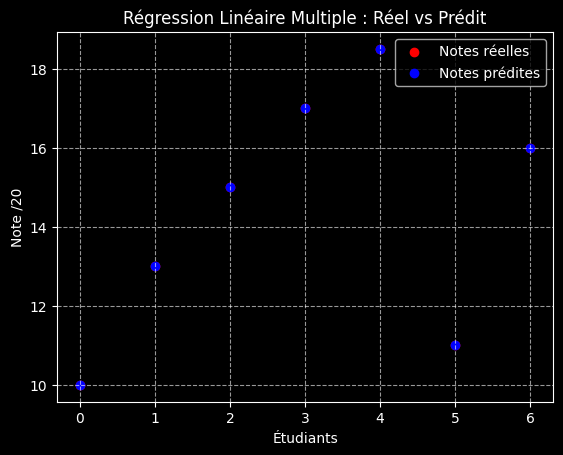

In [45]:
# ============================================================
# 9. VISUALISATION SIMPLE (comparaison réel vs prédit)
# ============================================================
predictions = X_b.dot(W)

plt.scatter(range(m), Y, color='red', label='Notes réelles')
plt.scatter(range(m), predictions, color='blue', label='Notes prédites')

plt.xlabel("Étudiants")
plt.ylabel("Note /20")
plt.title("Régression Linéaire Multiple : Réel vs Prédit")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# Dans une régression linéaire simple (une seule variable x),
# nous pouvons facilement tracer une ligne droite.
#
# Mais ici, nous avons 6 variables, ce qui signifie que notre
# "courbe" est en réalité un HYPERPLAN en 7 dimensions.
#
# Il est physiquement impossible de tracer cet hyperplan sur
# un écran en 2D. C'est pour cela que notre graphique affiche
# les points sur l'axe des "Étudiants" (une dimension
# arbitraire pour séparer les individus) plutôt que d'essayer
# de dessiner la fonction f(x1, x2, ..., x6).

--- Saisie des paramètres pour la prédiction ---

La note prédite pour ce profil est : 13.25/20


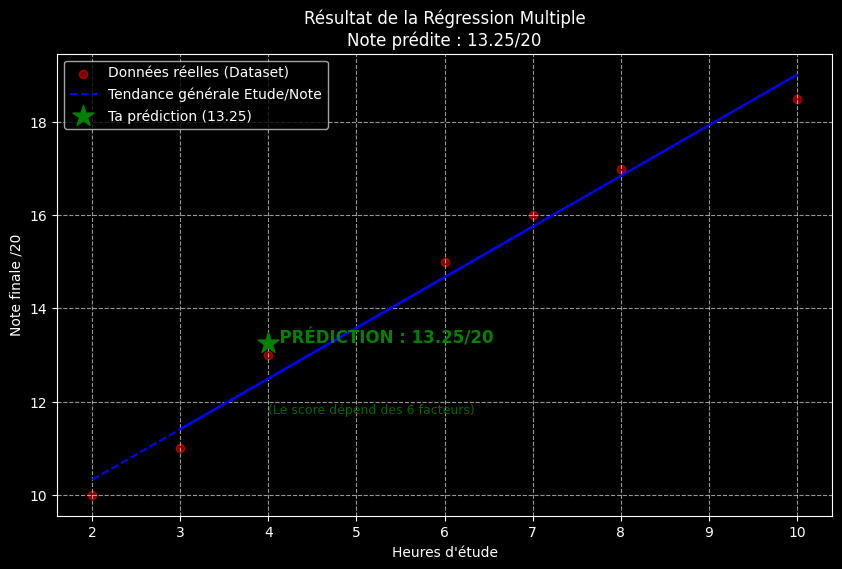

In [46]:
# ============================================================
# --- 1. SAISIE MANUELLE COMPLÈTE ---
# ============================================================
print("--- Saisie des paramètres pour la prédiction ---")
x1 = float(input("Heures d'étude : "))
x2 = float(input("Heures de sommeil : "))
x3 = float(input("Niveau de stress (1-10) : "))
x4 = float(input("Participation (%) : "))
x5 = float(input("Heures de sport : "))
x6 = float(input("Heures d'écran : "))

# Calcul de la prédiction matricielle : Note = W0*1 + W1*x1 + W2*x2 + ... + W6*x6
# Nous créons le vecteur avec TOUTES les saisies de l'utilisateur
X_point = np.array([[1, x1, x2, x3, x4, x5, x6]])
y_manuel = X_point.dot(W)[0][0]

print(f"\n La note prédite pour ce profil est : {y_manuel:.2f}/20")

# ============================================================
# --- 2. VISUALISATION ---
# ============================================================
plt.figure(figsize=(10, 6))

# Points réels du dataset (en rouge) pour comparaison
plt.scatter(heures_etude, notes_finales, color='red', alpha=0.5, label='Données réelles (Dataset)')

# NOTE : Comme nous avons 6 variables, nous ne pouvons pas tracer une seule "droite"
# qui passe par tous les points, car la note dépend aussi du sommeil, du sport, etc.
# Nous traçons ici une ligne de tendance basée UNIQUEMENT sur les heures d'étude.
m_h, b_h = np.polyfit(heures_etude, notes_finales, 1)
plt.plot(heures_etude, m_h*heures_etude + b_h, color='blue', linestyle='--', label='Tendance générale Etude/Note')

# AJOUT DU POINT MANUEL (en vert avec une étoile)
# Nous plaçons le point selon l'heure saisie (x1) et la note calculée (y_manuel)
plt.scatter(x1, y_manuel, color='green', s=250, marker='*', zorder=5, label=f'Ta prédiction ({y_manuel:.2f})')

# Annotation du point
plt.annotate(f"  PRÉDICTION : {y_manuel:.2f}/20", (x1, y_manuel),
             color='green', fontweight='bold', fontsize=12)

# Configuration du graphique
plt.xlabel("Heures d'étude")
plt.ylabel("Note finale /20")
plt.title(f"Résultat de la Régression Multiple\nNote prédite : {y_manuel:.2f}/20")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Rappel pédagogique en commentaire dans le graphe
plt.text(x1, y_manuel - 1.5, "(Le score dépend des 6 facteurs)", color='darkgreen', fontsize=9)

plt.show()

# ============================================================
# NOTE TECHNIQUE POUR NOUS :
# Dans une régression linéaire simple (une seule variable x),
# nous pouvons facilement tracer une ligne droite.
#
# Mais ici, nous avons 6 variables, ce qui signifie que notre
# "courbe" est en réalité un HYPERPLAN en 7 dimensions.
#
# Il est physiquement impossible de tracer cet hyperplan sur
# un écran en 2D. C'est pour cela que nous utilisons ce point
# étoilé pour montrer la position de l'étudiant dans cet espace.
# ============================================================